# 06 - SHAP Explainability

Explains individual anomaly predictions from the original full-featured Autoencoder (78 features, 82% recall) using SHAP. For each flagged flow, shows which features drove the high reconstruction error, turning a black-box anomaly score into a defensible, analyst-readable explanation.

In [1]:
import torch, joblib, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('/home/vboxuser/FEAR/data/cicids2017_cleaned.csv')
X = df.drop(columns=['Label', 'Binary_Label'])
y = df['Binary_Label']
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = joblib.load('/home/vboxuser/FEAR/models/scaler.pkl')
X_test_scaled = scaler.transform(X_test)

#### Rebuild architecture, load weights

In [2]:
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder(input_dim=X_test_scaled.shape[1])
model.load_state_dict(torch.load('/home/vboxuser/FEAR/models/autoencoder.pt'))
model.eval()
print('Model loaded')

Model loaded


#### Wrap model to output reconstruction error

In [3]:
class ReconstructionErrorModel(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        self.autoencoder = autoencoder
    def forward(self, x):
        recon = self.autoencoder(x)
        error = torch.mean((x - recon) ** 2, dim=1, keepdim=True)
        return error

wrapped_model = ReconstructionErrorModel(model)
wrapped_model.eval()

ReconstructionErrorModel(
  (autoencoder): Autoencoder(
    (encoder): Sequential(
      (0): Linear(in_features=78, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=16, bias=True)
      (3): ReLU()
      (4): Linear(in_features=16, out_features=8, bias=True)
      (5): ReLU()
    )
    (decoder): Sequential(
      (0): Linear(in_features=8, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=32, bias=True)
      (3): ReLU()
      (4): Linear(in_features=32, out_features=78, bias=True)
    )
  )
)

#### Build the SHAP explainer

In [6]:
import shap

background_idx = np.random.choice(len(X_test_scaled), 100, replace=False)
background = torch.FloatTensor(X_test_scaled[background_idx])

explainer = shap.GradientExplainer(wrapped_model, background)
print('Explainer ready')

Explainer ready


#### Get predictions and compute SHAP values for flagged anomalies

In [7]:
X_test_tensor = torch.FloatTensor(X_test_scaled)
with torch.no_grad():
    reconstructions = model(X_test_tensor)
    reconstruction_errors = torch.mean((X_test_tensor - reconstructions) ** 2, dim=1).numpy()

threshold = np.percentile(reconstruction_errors[y_test.values == 0], 80)
preds_binary = (reconstruction_errors > threshold).astype(int)

anomaly_indices = np.where((y_test.values == 1) & (preds_binary == 1))[0][:20]
X_explain = torch.FloatTensor(X_test_scaled[anomaly_indices])

shap_values = explainer.shap_values(X_explain)
print('SHAP values computed, shape:', np.array(shap_values).shape)

SHAP values computed, shape: (20, 78, 1)


#### Visualize

In [9]:
shap_values_squeezed = shap_values.squeeze(-1)
print(shap_values_squeezed.shape)

(20, 78)


/tmp/ipykernel_39395/588643965.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_squeezed, X_explain.numpy(), feature_names=feature_names, show=False)


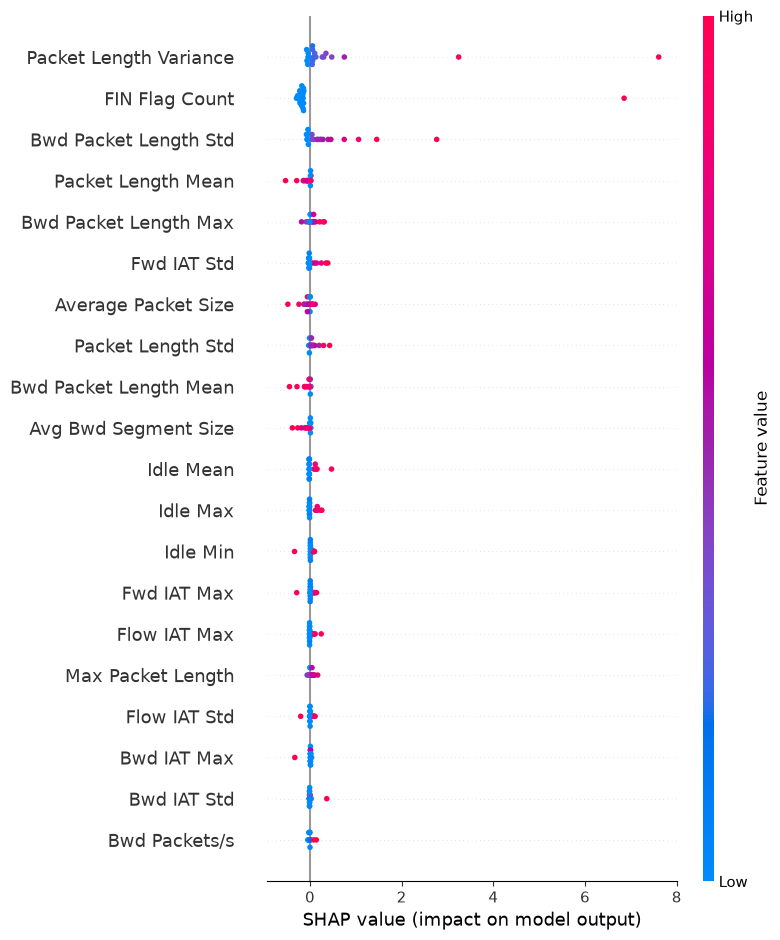

In [11]:
import matplotlib.pyplot as plt

feature_names = X.columns.tolist()
shap.summary_plot(shap_values_squeezed, X_explain.numpy(), feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('/home/vboxuser/FEAR/results/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

#### Waterfall plot for one specific flow

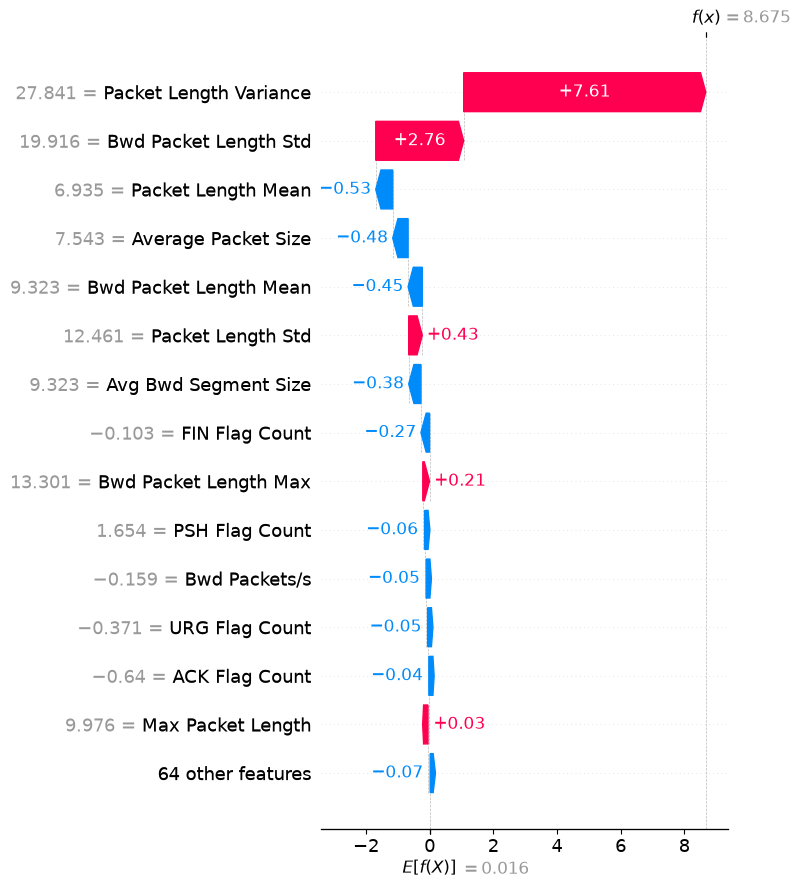

In [13]:
# Pick the flow with the highest reconstruction error among your 20 samples — the most dramatic example
top_flow_idx = np.argmax(reconstruction_errors[anomaly_indices])

explanation = shap.Explanation(
    values=shap_values_squeezed[top_flow_idx],
    base_values=shap_values_squeezed.mean(),  # approximate baseline
    data=X_explain.numpy()[top_flow_idx],
    feature_names=feature_names
)

plt.figure()
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.tight_layout()
plt.savefig('/home/vboxuser/FEAR/results/shap_waterfall_single_flow.png', dpi=150, bbox_inches='tight')
plt.show()

#### Bar chart of mean absolute SHAP values

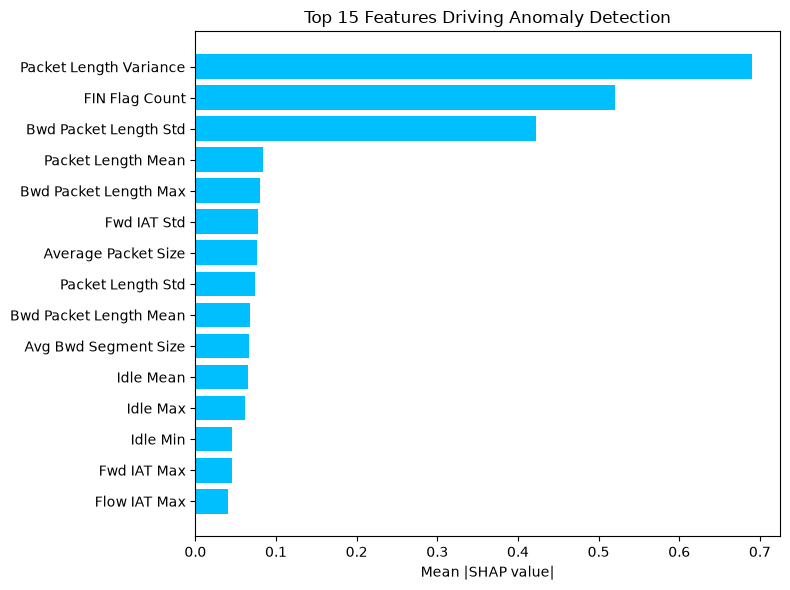

In [15]:
mean_abs_shap = np.abs(shap_values_squeezed).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'][::-1], importance_df['mean_abs_shap'][::-1], color='deepskyblue')
plt.xlabel('Mean |SHAP value|')
plt.title('Top 15 Features Driving Anomaly Detection')
plt.tight_layout()
plt.savefig('/home/vboxuser/FEAR/results/shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()